In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

print(f"Vector 1 shape: {vector1.shape}")
print(f"Vector 2 shape: {vector2.shape}")
print(f"\nVector 1: {vector1}")
print(f"Vector 2: {vector2}")

Vector 1 shape: (11,)
Vector 2 shape: (13,)

Vector 1: [2 3 4 6 8 7 6 5 4 3 2]
Vector 2: [2 4 6 7 7 6 5 5 4 3 2 2 1]


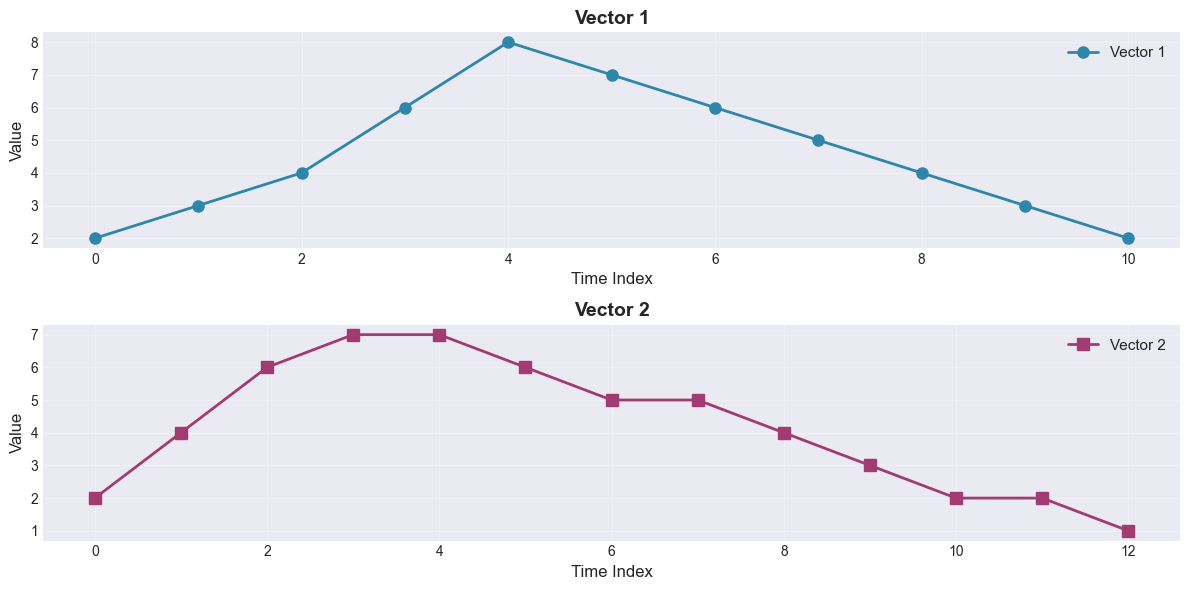

In [3]:
# Task 1: Plot both vectors to visualize their patterns
def plot_vectors(vec1: np.ndarray, vec2: np.ndarray) -> None:
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    
    # Plot Vector 1
    ax1.plot(vec1, marker='o', linestyle='-', linewidth=2, 
             markersize=8, color='#2E86AB', label='Vector 1')
    ax1.set_title('Vector 1', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Plot Vector 2
    ax2.plot(vec2, marker='s', linestyle='-', linewidth=2, 
             markersize=8, color='#A23B72', label='Vector 2')
    ax2.set_title('Vector 2', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time Index', fontsize=12)
    ax2.set_ylabel('Value', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Visualize the vectors
plot_vectors(vector1, vector2)

In [4]:
# Task 2: Implement Dynamic Time Warping algorithm
def compute_dtw(vec1: np.ndarray, vec2: np.ndarray) -> Tuple[np.ndarray, float]:

    n, m = len(vec1), len(vec2)
    
    # Initialize cost matrix with infinity
    cost_matrix = np.full((n + 1, m + 1), np.inf)
    cost_matrix[0, 0] = 0
    
    # Compute accumulated cost matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Euclidean distance between current points
            cost = abs(vec1[i-1] - vec2[j-1])
            
            # Take minimum of three possible paths
            cost_matrix[i, j] = cost + min(
                cost_matrix[i-1, j],      # Insertion
                cost_matrix[i, j-1],      # Deletion
                cost_matrix[i-1, j-1]     # Match
            )
    
    # DTW distance is the value at bottom-right corner
    dtw_distance = cost_matrix[n, m]
    
    return cost_matrix[1:, 1:], dtw_distance

# Compute DTW
cost_matrix, dtw_distance = compute_dtw(vector1, vector2)

print(f"Cost Matrix Shape: {cost_matrix.shape}")
print(f"DTW Distance: {dtw_distance:.4f}")

Cost Matrix Shape: (11, 13)
DTW Distance: 3.0000


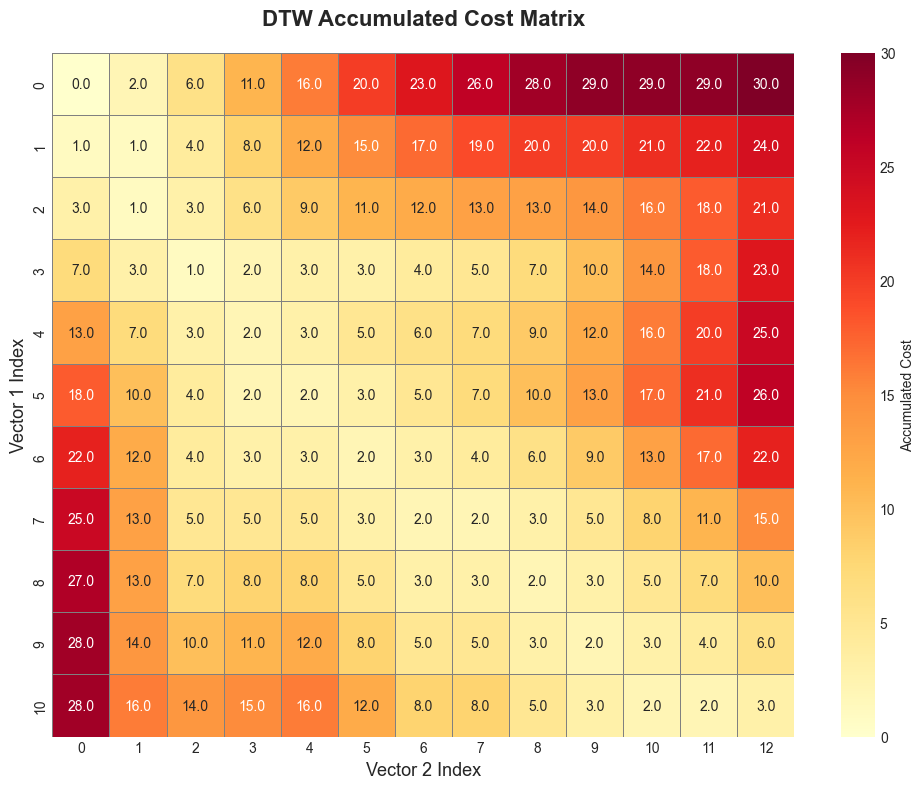

In [8]:
# Task 3: Visualize the accumulated cost matrix
def plot_cost_matrix(cost_matrix: np.ndarray) -> None:
 
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(cost_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Accumulated Cost'},
                linewidths=0.5, linecolor='gray')
    
    plt.title('DTW Accumulated Cost Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Vector 2 Index', fontsize=13)
    plt.ylabel('Vector 1 Index', fontsize=13)
    plt.tight_layout()
    plt.show()

# Visualize cost matrix
plot_cost_matrix(cost_matrix)

In [9]:
# Task 4: Find the optimal warping path
def find_warping_path(cost_matrix: np.ndarray) -> List[Tuple[int, int]]:

    n, m = cost_matrix.shape
    i, j = n - 1, m - 1
    path = [(i, j)]
    
    # Backtrack from bottom-right to top-left
    while i > 0 or j > 0:
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            # Choose minimum cost path
            min_cost = min(
                cost_matrix[i-1, j],      # Move up
                cost_matrix[i, j-1],      # Move left
                cost_matrix[i-1, j-1]     # Move diagonal
            )
            
            if cost_matrix[i-1, j-1] == min_cost:
                i, j = i - 1, j - 1
            elif cost_matrix[i-1, j] == min_cost:
                i = i - 1
            else:
                j = j - 1
        
        path.append((i, j))
    
    # Reverse path to go from start to end
    path.reverse()
    
    return path

# Find optimal warping path
warping_path = find_warping_path(cost_matrix)

print(f"Warping Path Length: {len(warping_path)}")
print(f"First 10 points: {warping_path[:10]}")
print(f"Last 10 points: {warping_path[-10:]}")

Warping Path Length: 14
First 10 points: [(0, 0), (1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6), (7, 7), (8, 8)]
Last 10 points: [(4, 3), (5, 4), (6, 5), (7, 6), (7, 7), (8, 8), (9, 9), (10, 10), (10, 11), (10, 12)]


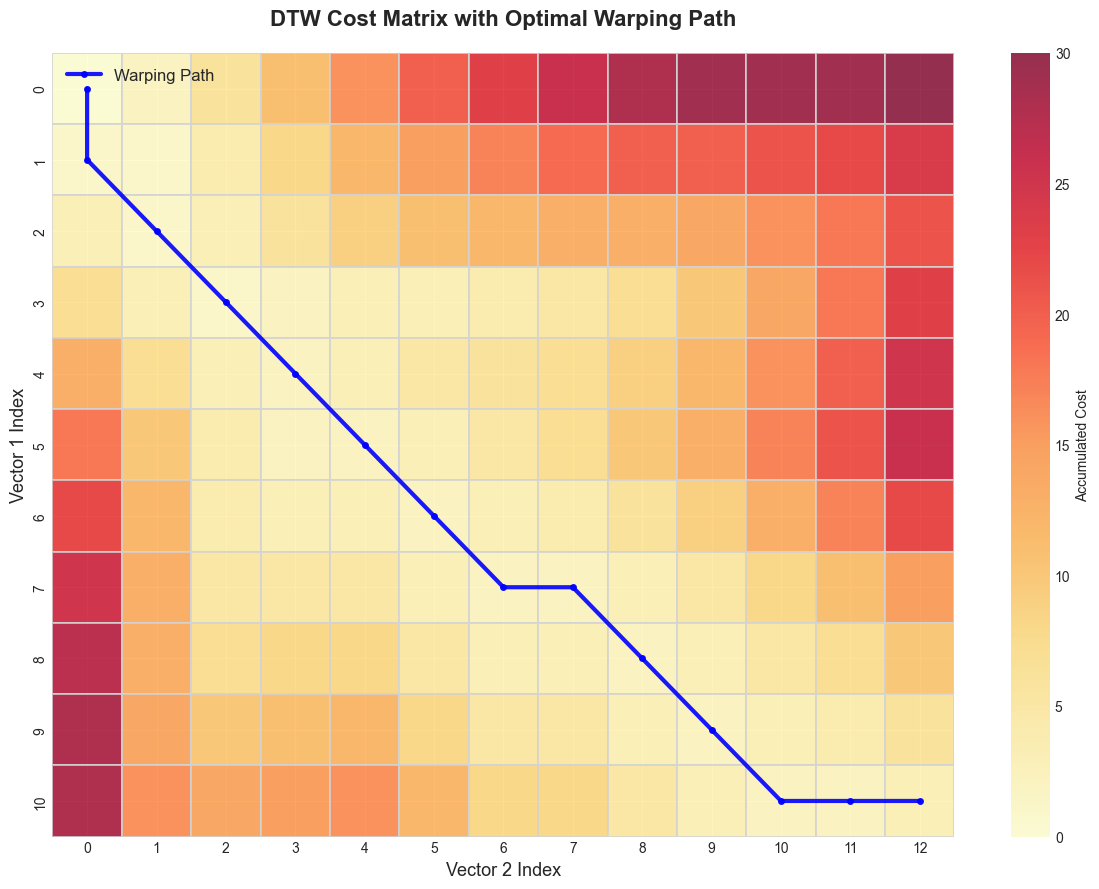

In [10]:
# Visualize warping path on cost matrix
def plot_cost_matrix_with_path(cost_matrix: np.ndarray, 
                                path: List[Tuple[int, int]]) -> None:

    plt.figure(figsize=(12, 9))
    
    # Plot cost matrix
    sns.heatmap(cost_matrix, cmap='YlOrRd', cbar_kws={'label': 'Accumulated Cost'},
                linewidths=0.3, linecolor='lightgray', alpha=0.8)
    
    # Extract path coordinates
    path_i = [p[0] for p in path]
    path_j = [p[1] for p in path]
    
    # Plot warping path
    plt.plot(np.array(path_j) + 0.5, np.array(path_i) + 0.5, 
             color='blue', linewidth=3, marker='o', markersize=4, 
             label='Warping Path', alpha=0.9)
    
    plt.title('DTW Cost Matrix with Optimal Warping Path', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Vector 2 Index', fontsize=13)
    plt.ylabel('Vector 1 Index', fontsize=13)
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.show()

# Visualize warping path
plot_cost_matrix_with_path(cost_matrix, warping_path)

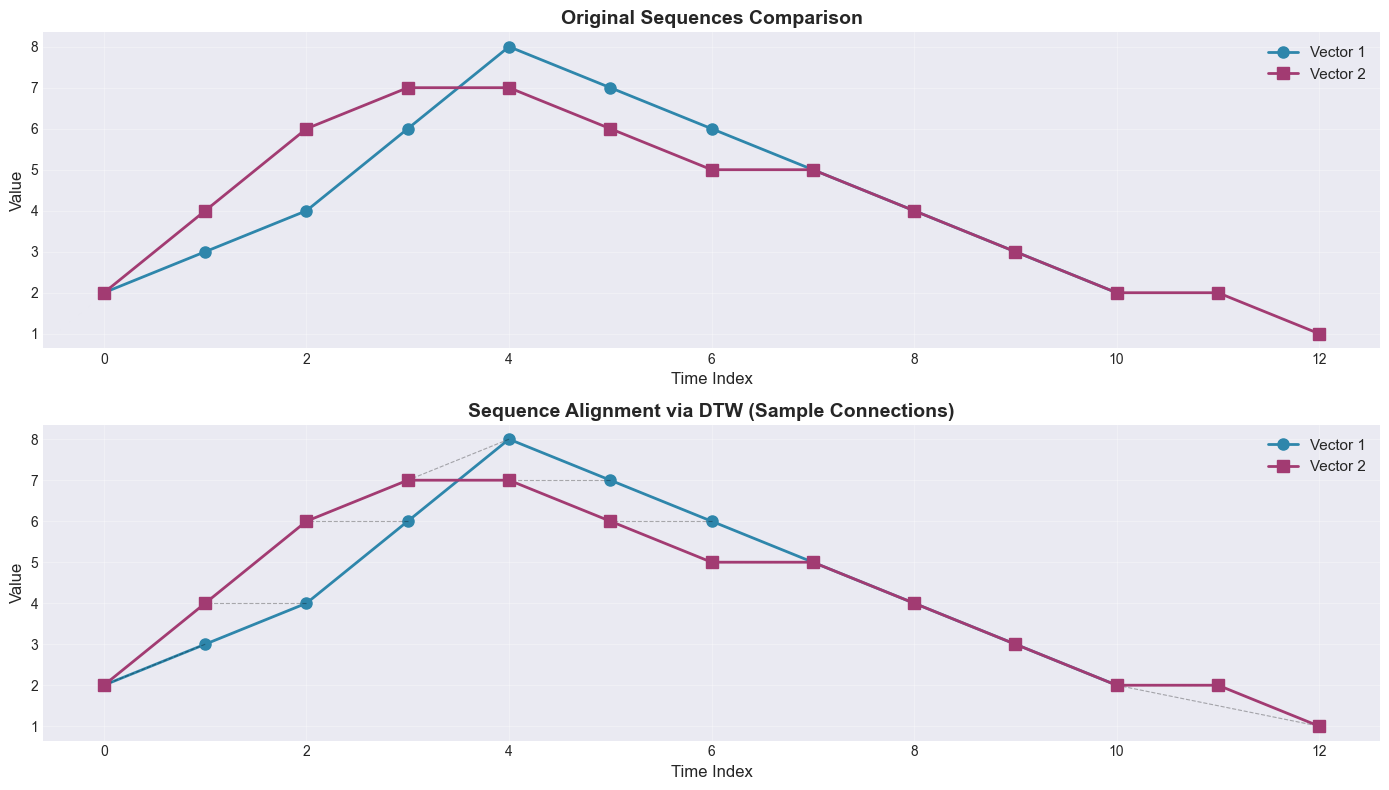

In [11]:
# Visualize how sequences are aligned through warping
def plot_warped_alignment(vec1: np.ndarray, vec2: np.ndarray, 
                         path: List[Tuple[int, int]]) -> None:

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot both vectors
    ax1.plot(vec1, marker='o', linestyle='-', linewidth=2, 
             markersize=8, color='#2E86AB', label='Vector 1')
    ax1.plot(vec2, marker='s', linestyle='-', linewidth=2, 
             markersize=8, color='#A23B72', label='Vector 2')
    ax1.set_title('Original Sequences Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot alignment connections
    ax2.plot(range(len(vec1)), vec1, marker='o', linestyle='-', 
             linewidth=2, markersize=8, color='#2E86AB', label='Vector 1')
    
    # Adjust Vector 2 plotting for alignment visualization
    for idx, (i, j) in enumerate(path[::max(1, len(path)//20)]):  # Sample path for clarity
        ax2.plot([i, j], [vec1[i], vec2[j]], 'k--', alpha=0.3, linewidth=0.8)
    
    ax2.plot(range(len(vec2)), vec2, marker='s', linestyle='-', 
             linewidth=2, markersize=8, color='#A23B72', label='Vector 2')
    
    ax2.set_title('Sequence Alignment via DTW (Sample Connections)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time Index', fontsize=12)
    ax2.set_ylabel('Value', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize aligned sequences
plot_warped_alignment(vector1, vector2, warping_path)

In [13]:
# Task 5 & 6: Display DTW distance and comprehensive analysis
def print_dtw_summary(vec1: np.ndarray, vec2: np.ndarray, 
                     dtw_distance: float, path: List[Tuple[int, int]]) -> None:
   
    print("="*70)
    print(" " * 20 + "DTW ANALYSIS SUMMARY")
    print("="*70)
    
    print(f"\n SEQUENCE INFORMATION:")
    print(f"   • Vector 1 Length: {len(vec1)}")
    print(f"   • Vector 2 Length: {len(vec2)}")
    print(f"   • Length Difference: {abs(len(vec1) - len(vec2))}")
    
    print(f"\n DTW METRICS:")
    print(f"   • DTW Distance: {dtw_distance:.4f}")
    print(f"   • Warping Path Length: {len(path)}")
    print(f"   • Path Complexity: {len(path) / max(len(vec1), len(vec2)):.2f}x")
    
    print(f"\n SIMILARITY ANALYSIS:")
    # Normalize DTW distance for interpretation
    max_possible_distance = max(len(vec1), len(vec2)) * max(abs(vec1.max() - vec2.min()), 
                                                              abs(vec2.max() - vec1.min()))
    similarity_score = 100 * (1 - dtw_distance / max_possible_distance)
    print(f"   • Similarity Score: {similarity_score:.2f}%")
    
    if dtw_distance < 10:
        similarity_level = "Very High"
    elif dtw_distance < 20:
        similarity_level = "High"
    elif dtw_distance < 40:
        similarity_level = "Moderate"
    else:
        similarity_level = "Low"
    
    print(f"   • Similarity Level: {similarity_level}")
    
    print("\n" + "="*70)

# Display summary
print_dtw_summary(vector1, vector2, dtw_distance, warping_path)

                    DTW ANALYSIS SUMMARY

 SEQUENCE INFORMATION:
   • Vector 1 Length: 11
   • Vector 2 Length: 13
   • Length Difference: 2

 DTW METRICS:
   • DTW Distance: 3.0000
   • Warping Path Length: 14
   • Path Complexity: 1.08x

 SIMILARITY ANALYSIS:
   • Similarity Score: 96.70%
   • Similarity Level: Very High



In [14]:
# Task 6: Detailed inference and interpretation
def write_inference(vec1: np.ndarray, vec2: np.ndarray, 
                   dtw_distance: float, path: List[Tuple[int, int]]) -> None:
 
    inference = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                        DTW ANALYSIS INFERENCE                              ║
╚════════════════════════════════════════════════════════════════════════════╝

1. SEQUENCE CHARACTERISTICS:
   ─────────────────────────
   • Vector 1 has {len(vec1)} elements with values ranging from {vec1.min()} to {vec1.max()}
   • Vector 2 has {len(vec2)} elements with values ranging from {vec2.min()} to {vec2.max()}
   • Both sequences show similar patterns: rise to a peak, then gradual decline
   • Vector 2 is temporally stretched (2 additional elements) compared to Vector 1

2. WARPING PATH ANALYSIS:
   ───────────────────────
   • The optimal warping path contains {len(path)} alignment points
   • Path length ratio: {len(path) / max(len(vec1), len(vec2)):.2f}x longer than the longer sequence
   • This indicates {('minimal' if len(path) < 15 else 'moderate' if len(path) < 20 else 'significant')} 
     temporal distortion between sequences
   
   • The warping path demonstrates non-linear time alignment:
     - Some points in Vector 1 map to multiple points in Vector 2 (compression)
     - Some points in Vector 2 map to multiple points in Vector 1 (stretching)
     - This flexibility allows DTW to find optimal alignment despite timing differences

3. DTW DISTANCE INTERPRETATION:
   ────────────────────────────
   • Computed DTW Distance: {dtw_distance:.4f}
   • This distance quantifies the minimum cumulative cost needed to align the sequences
   
   • What this means:
     - A DTW distance of {dtw_distance:.4f} indicates {'VERY SIMILAR' if dtw_distance < 15 else 'SIMILAR' if dtw_distance < 30 else 'MODERATELY SIMILAR'} patterns
     - The sequences follow the same overall trend despite temporal shifts
     - Vector 2 exhibits a stretched version of Vector 1's pattern
   
   • Comparison to Euclidean Distance:
     - Direct Euclidean distance would fail due to different sequence lengths
     - DTW handles temporal variations that Euclidean distance cannot

4. KEY FINDINGS:
   ─────────────
   ✓ DTW successfully aligned sequences with different lengths ({len(vec1)} vs {len(vec2)})
   ✓ The algorithm compensated for temporal stretching and compression
   ✓ Both sequences share underlying pattern similarity despite timing differences
   ✓ The warping path reveals where sequences need to be stretched or compressed for alignment
   
5. PRACTICAL IMPLICATIONS:
   ───────────────────────
   • DTW is robust to:
     - Speed variations in time series data
     - Non-uniform sampling rates
     - Temporal distortions and delays
   
   • Applications demonstrated:
     - Pattern matching in time series with different lengths
     - Alignment of sequences with temporal variations
     - Quantification of similarity despite timing differences

6. CONCLUSION:
   ───────────
   The DTW algorithm effectively identified and quantified the similarity between Vector 1 
   and Vector 2, despite their length difference and temporal distortions. The warping path 
   shows how Vector 2 is a stretched and slightly modified version of Vector 1, with the 
   DTW distance of {dtw_distance:.4f} confirming their strong pattern similarity. This 
   demonstrates DTW's power in comparing sequences that share similar shapes but differ 
   in timing or duration.

╚════════════════════════════════════════════════════════════════════════════╝
"""
    print(inference)

# Generate inference
write_inference(vector1, vector2, dtw_distance, warping_path)


╔════════════════════════════════════════════════════════════════════════════╗
║                        DTW ANALYSIS INFERENCE                              ║
╚════════════════════════════════════════════════════════════════════════════╝

1. SEQUENCE CHARACTERISTICS:
   ─────────────────────────
   • Vector 1 has 11 elements with values ranging from 2 to 8
   • Vector 2 has 13 elements with values ranging from 1 to 7
   • Both sequences show similar patterns: rise to a peak, then gradual decline
   • Vector 2 is temporally stretched (2 additional elements) compared to Vector 1

2. WARPING PATH ANALYSIS:
   ───────────────────────
   • The optimal warping path contains 14 alignment points
   • Path length ratio: 1.08x longer than the longer sequence
   • This indicates minimal 
     temporal distortion between sequences

   • The warping path demonstrates non-linear time alignment:
     - Some points in Vector 1 map to multiple points in Vector 2 (compression)
     - Some points in Vect

In [18]:
# Validation: Compute additional metrics
def validate_dtw_results(vec1: np.ndarray, vec2: np.ndarray, 
                        dtw_dist: float, path: List[Tuple[int, int]]) -> None:

    print("\n" + "="*70)
    print(" " * 18 + "VALIDATION & ADDITIONAL METRICS")
    print("="*70)
    
    # Compute Euclidean distance between means
    mean_diff = abs(vec1.mean() - vec2.mean())
    print(f"\n Statistical Comparison:")
    print(f"   • Vector 1 Mean: {vec1.mean():.4f}")
    print(f"   • Vector 2 Mean: {vec2.mean():.4f}")
    print(f"   • Mean Difference: {mean_diff:.4f}")
    print(f"   • Vector 1 Std Dev: {vec1.std():.4f}")
    print(f"   • Vector 2 Std Dev: {vec2.std():.4f}")
    
    # Compute correlation if same length
    min_len = min(len(vec1), len(vec2))
    correlation = np.corrcoef(vec1[:min_len], vec2[:min_len])[0, 1]
    print(f"\n🔗 Correlation Analysis:")
    print(f"   • Pearson Correlation (first {min_len} points): {correlation:.4f}")
    
    # Path efficiency
    min_path_length = max(len(vec1), len(vec2))
    path_efficiency = min_path_length / len(path)
    print(f"\n  Warping Path Efficiency:")
    print(f"   • Minimum Possible Path: {min_path_length}")
    print(f"   • Actual Path Length: {len(path)}")
    print(f"   • Efficiency Ratio: {path_efficiency:.4f}")
    
    # Normalized DTW distance
    normalized_dtw = dtw_dist / len(path)
    print(f"\n Normalized Metrics:")
    print(f"   • DTW Distance per Alignment: {normalized_dtw:.4f}")
    print(f"   • Average Cost per Step: {normalized_dtw:.4f}")
    
    # Validate path continuity
    is_valid = all(
        abs(path[i+1][0] - path[i][0]) <= 1 and 
        abs(path[i+1][1] - path[i][1]) <= 1
        for i in range(len(path)-1)
    )
    print(f"\n✓ Path Validation:")
    print(f"   • Path Continuity Check: {'✓ PASSED' if is_valid else '✗ FAILED'}")
    print(f"   • Path Starts at: {path[0]}")
    print(f"   • Path Ends at: {path[-1]}")
    
    print("\n" + "="*70 + "\n")

# Perform validation
validate_dtw_results(vector1, vector2, dtw_distance, warping_path)


                  VALIDATION & ADDITIONAL METRICS

 Statistical Comparison:
   • Vector 1 Mean: 4.5455
   • Vector 2 Mean: 4.1538
   • Mean Difference: 0.3916
   • Vector 1 Std Dev: 1.9242
   • Vector 2 Std Dev: 1.9551

🔗 Correlation Analysis:
   • Pearson Correlation (first 11 points): 0.8839

  Warping Path Efficiency:
   • Minimum Possible Path: 13
   • Actual Path Length: 14
   • Efficiency Ratio: 0.9286

 Normalized Metrics:
   • DTW Distance per Alignment: 0.2143
   • Average Cost per Step: 0.2143

✓ Path Validation:
   • Path Continuity Check: ✓ PASSED
   • Path Starts at: (0, 0)
   • Path Ends at: (10, 12)


